# Homework 7

## Juhi Malwade

Student Name: Juhi Malwade

Student UT EID: jm97555

---

Date Created: 3/23/26

Date Last Modified: 3/23/26

---

Totoal Points 20. 



## Supprt Vector Machine 

In [120]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [121]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task - 1 Implement SVM using libraries (4 points)
We want to use **Suppert Vector Machine** to perdict if the patients will have heart problems or not. The column "Target" in our datasets includes data about heart diseases. If the patient had heart disease we have a 1 and if not a zero. 

Prepare your data set for predicting heart disease ("Target" column) out of 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 


Split your data into 80% traning data and 20% test data, and implement Support Vector Machine using Scikit-Learn. 





In [122]:
X = heart_df[['Age', 'Sex', 'Chol']].values

heart_df['Target'] = heart_df['Target'].map({'No': 1, 'Yes': 0})
y = heart_df['Target'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [123]:
from sklearn import svm
from sklearn.metrics import accuracy_score

model = svm.SVC()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.5081967213114754


# Task 2 - (4 points)

Cacluate the accuracy, Precision, Recall and F1 score of your **SVM** implementaion from Task 1. 
Print the results. 

You may use library methods for this task if you choose to.


In [124]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.39      0.27      0.32        26
           1       0.56      0.69      0.62        35

    accuracy                           0.51        61
   macro avg       0.47      0.48      0.47        61
weighted avg       0.49      0.51      0.49        61



# Task 3 - Implement SVM without using libraries  - (4 points)

Implement SVM from scratch using Hinge Loss function and Gradient Descent. 
Try to produce the same result as you get from the libraries. 


* Do as many iterations as needed 
* Do maximum **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher. 
* Visualize your costs. 
* No need to add an y-intercept in this task. 
* You can use libraries to report accuracy, Precision, Recall and F1. 



In [125]:
def compute_cost(X, y, W, regularization_factor):
    '''This function calculate the hinge loss. Primal Problem in SVM'''
    n = X.shape[0]
    distances = 1 - y * (np.dot(X, W))

    # This is our max(0, distance). 
    distances[distances < 0] = 0 

    hinge_loss = regularization_factor * (np.sum(distances) / n)
    # This divide by 2 is not important. You can skip doing it 
    # because we want only to check if this cost is going down or not. 
    return (1 / 2 * np.dot(W, W) + hinge_loss)

In [126]:
def calculate_gradient(X, y, W, regularization_factor):

    if type(y) == np.float64:
        y = np.array([y])
        X = np.array([X])

    distance = 1 - (y * np.dot(X, W))

    dw = np.zeros(len(W))

    for ind, d in enumerate(distance):

        if (d < 0):
            di = W
        else:
            di = W - (regularization_factor * y[ind] * X[ind])


        dw += di

    dw = dw/len(y)  # average

    return dw

In [127]:
weights = np.zeros(3)


# Now we optimize it using Gradient Descent.
num_iterations = 100
learnin_rate = 0.01

regularization = 0.01

cost_list = []

for i in range(0, num_iterations):

    cost = compute_cost(X_train, y_train, weights, regularization)

    print("Epoch", i, "Cost is:", cost, "weights", weights)

    cost_list.append(cost)

    grad = calculate_gradient(X_train, y_train, weights, regularization)

    weights = weights - learnin_rate * grad

Epoch 0 Cost is: 0.01 weights [0. 0. 0.]
Epoch 1 Cost is: 0.00475441946144389 weights [2.78925620e-03 3.22314050e-05 1.27363636e-02]
Epoch 2 Cost is: 0.004752728001764463 weights [2.76136364e-03 3.19090909e-05 1.26090000e-02]
Epoch 3 Cost is: 0.004751070202132656 weights [2.733750e-03 3.159000e-05 1.248291e-02]
Epoch 4 Cost is: 0.004749445392713522 weights [2.70641250e-03 3.12741000e-05 1.23580809e-02]
Epoch 5 Cost is: 0.004747852917001828 weights [2.67934838e-03 3.09613590e-05 1.22345001e-02]
Epoch 6 Cost is: 0.004746292131556798 weights [2.65255489e-03 3.06517454e-05 1.21121551e-02]
Epoch 7 Cost is: 0.0047447624057421235 weights [2.62602934e-03 3.03452280e-05 1.19910335e-02]
Epoch 8 Cost is: 0.0047432631214711606 weights [2.59976905e-03 3.00417757e-05 1.18711232e-02]
Epoch 9 Cost is: 0.00474179367295719 weights [2.57377136e-03 2.97413579e-05 1.17524120e-02]
Epoch 10 Cost is: 0.0047403534664686485 weights [2.54803364e-03 2.94439443e-05 1.16348879e-02]
Epoch 11 Cost is: 0.0047389419200

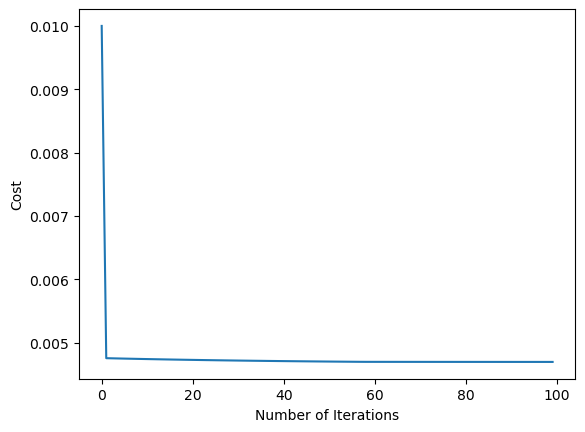

In [128]:
plt.plot(np.arange(num_iterations), cost_list)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.show()

In [129]:
def predict_svm(weights, X):
    """
    Predict the class between 0 and 1 using learned SVM parameters weights.
    """
    return np.where(np.dot(X, weights)<0, -1, 1)

In [130]:
print("Accuracy Score:", accuracy_score(y_test, predict_svm(weights, X_test)))

Accuracy Score: 0.5737704918032787


In [131]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.39      0.27      0.32        26
           1       0.56      0.69      0.62        35

    accuracy                           0.51        61
   macro avg       0.47      0.48      0.47        61
weighted avg       0.49      0.51      0.49        61



# Task 4 - Compare SVM results with Logistic Regression - (4 points)

Which model performs better here? Compare your results wit the logistic regression. You can use libraries for this task, it is not necessary to implement logistic regression from sratch.


In [132]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression( fit_intercept=True)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7540983606557377
              precision    recall  f1-score   support

           0       0.69      0.77      0.73        26
           1       0.81      0.74      0.78        35

    accuracy                           0.75        61
   macro avg       0.75      0.76      0.75        61
weighted avg       0.76      0.75      0.76        61



Logistic Regression performed better. It had an accuracy of 0.75, while the SVM had an accuracy of 0.51. The precision, recall, and f1-scores are all higher for the logistic regression compared to the SVM.

# Task 5 - Apply a kernel function to improve SVM performance (4 points)

Use the Scikit-learn librariy and apply a kernel function to improve the SVM performance. Check if this is possible. 


In [133]:
rbf_kernel = svm.SVC(kernel='rbf', random_state=0)

rbf_kernel.fit(X_train, y_train)

y_pred_kernel = rbf_kernel.predict(X_test)

print("Accuracy Score (RBF kernel):", accuracy_score(y_test, y_pred_kernel))
print("\nClassification Report (RBF kernel):")
print(classification_report(y_test, y_pred_kernel))

Accuracy Score (RBF kernel): 0.5081967213114754

Classification Report (RBF kernel):
              precision    recall  f1-score   support

           0       0.39      0.27      0.32        26
           1       0.56      0.69      0.62        35

    accuracy                           0.51        61
   macro avg       0.47      0.48      0.47        61
weighted avg       0.49      0.51      0.49        61



### The rbf kernel did not improve the SVM performance.

In [134]:
linear_kernel = svm.SVC(kernel='linear', random_state=0)

linear_kernel.fit(X_train, y_train)

y_pred_kernel = linear_kernel.predict(X_test)

print("Accuracy Score (linear kernel):", accuracy_score(y_test, y_pred_kernel))
print("\nClassification Report (linear kernel):")
print(classification_report(y_test, y_pred_kernel))

Accuracy Score (linear kernel): 0.7377049180327869

Classification Report (linear kernel):
              precision    recall  f1-score   support

           0       0.66      0.81      0.72        26
           1       0.83      0.69      0.75        35

    accuracy                           0.74        61
   macro avg       0.74      0.75      0.74        61
weighted avg       0.75      0.74      0.74        61



### The linear kernel improved the SVM performance the most.

In [135]:
poly_kernel = svm.SVC(kernel='poly', random_state=0)

poly_kernel.fit(X_train, y_train)

y_pred_kernel = poly_kernel.predict(X_test)

print("Accuracy Score (poly kernel):", accuracy_score(y_test, y_pred_kernel))
print("\nClassification Report (poly kernel):")
print(classification_report(y_test, y_pred_kernel))

Accuracy Score (poly kernel): 0.5737704918032787

Classification Report (poly kernel):
              precision    recall  f1-score   support

           0       0.50      0.38      0.43        26
           1       0.61      0.71      0.66        35

    accuracy                           0.57        61
   macro avg       0.55      0.55      0.55        61
weighted avg       0.56      0.57      0.56        61



### The poly kernel slightly improved the SVM performance.